# Synthetic car-park charging-demand profile

How much power does a workplace car park need once its fleet goes electric?
There is no meter to read, so I have to build the load from behaviour instead:
when cars arrive and leave, how many sit there at once, and what each charger
draws. This notebook builds a 24-hour load curve from a small behavioural model
and reads off the peak the site has to support.

Two groups share the car park. Customers come and go through the day, with a
mid-morning arrival peak and a smaller afternoon one. Employees arrive tightly
around the start of the working day and leave just as tightly at the end. Each
group gets a mixture-of-Gaussians arrival distribution (a weighted sum of bell
curves) and a matching departure distribution over the hour of the day.

The generation engine and the fitted parameters are withheld from the public
release, so the heavy sampling runs in `scripts/generate_profiles.py` and is
read back here from `artifacts/`.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from evattendance.plotting import palette, save_figure, setup_style


def project_root() -> Path:
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / "pyproject.toml").exists() and (parent / "src" / "evattendance").exists():
            return parent
    return Path.cwd()


setup_style()
ROOT = project_root()
ARTIFACTS = ROOT / "artifacts"
meta = json.loads((ARTIFACTS / "meta.json").read_text())
densities = pd.read_parquet(ARTIFACTS / "densities.parquet")
profile = pd.read_parquet(ARTIFACTS / "profile.parquet")
categories = [category["name"] for category in meta["categories"]]
categories

['customer', 'employee']

## The behavioural distributions

Start with the curves, because everything downstream is just sampling from
them. Each is a normalised density over the hour of the day. The customer
arrival density is bimodal, a morning rush and an afternoon shoulder, and the
departure density mirrors it later in the day. The employee densities are
narrow spikes at the start and end of the working day. These four shapes are
the whole model.

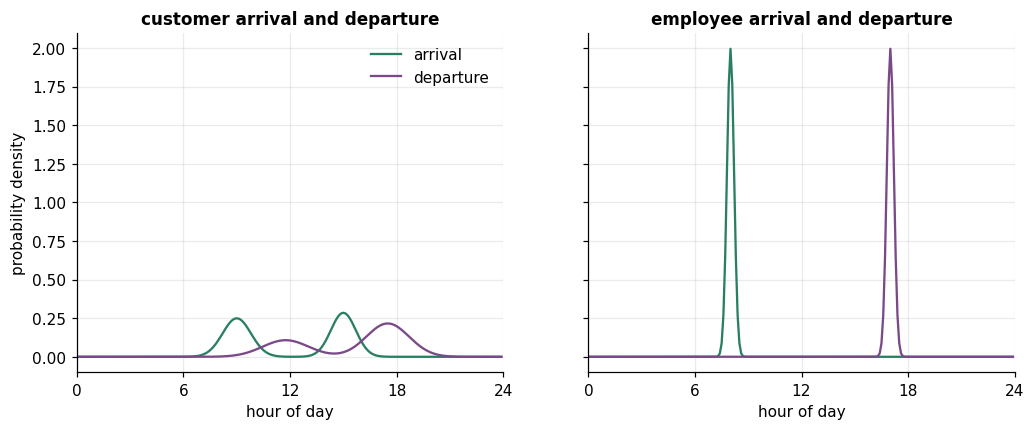

In [2]:
fig, axes = plt.subplots(1, len(categories), figsize=(11, 4), sharey=True)
for ax, name in zip(axes, categories, strict=True):
    ax.plot(
        densities["hour"], densities[f"{name}_arrival"], color=palette("arrival"), label="arrival"
    )
    ax.plot(
        densities["hour"],
        densities[f"{name}_departure"],
        color=palette("departure"),
        label="departure",
    )
    ax.set_title(f"{name} arrival and departure")
    ax.set_xlabel("hour of day")
    ax.set_xlim(0, 24)
    ax.set_xticks(range(0, 25, 6))
axes[0].set_ylabel("probability density")
axes[0].legend()
plt.show()

## Occupancy through the day

Now turn the curves into vehicles. Sample an arrival and a departure time for
every car, then count how many are present at each step. That gives an
occupancy curve per group. Departures are constrained to fall after arrivals,
so the count is a real dwell-time occupancy, not the difference of two
independent draws. The employee count comes out as a near-rectangular block
over the working day; the customer count is broader and rounder.

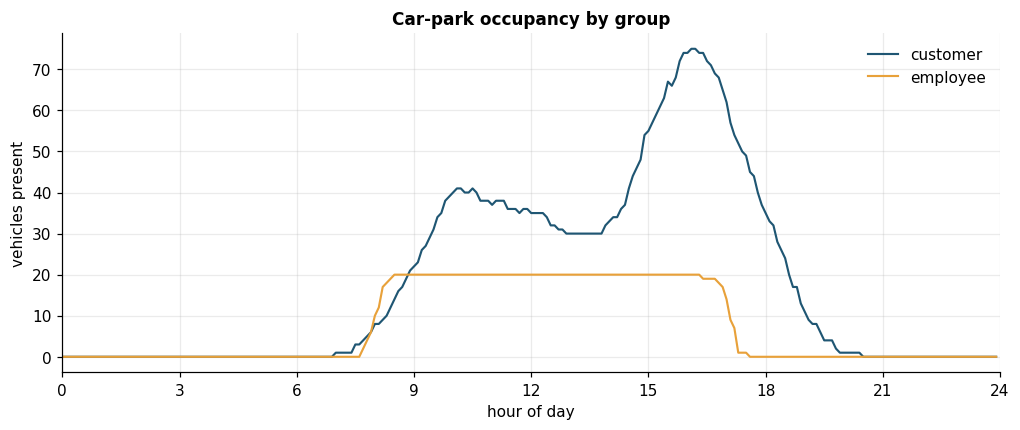

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
for name in categories:
    ax.plot(profile["hour"], profile[f"count_{name}"], color=palette(name), lw=1.4, label=name)
ax.set_xlabel("hour of day")
ax.set_ylabel("vehicles present")
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 3))
ax.set_title("Car-park occupancy by group")
ax.legend()
plt.show()

## The load curve

Multiply occupancy by the charger rating, sum the groups, and you have the car
park's charging load through the day. The peak is what the supply has to be
sized for. It lands in the middle of the day, where customer and employee
occupancy overlap, and it sits well below the naive sum of every charger
running at once. That gap is the whole point of modelling the behaviour rather
than assuming the worst.

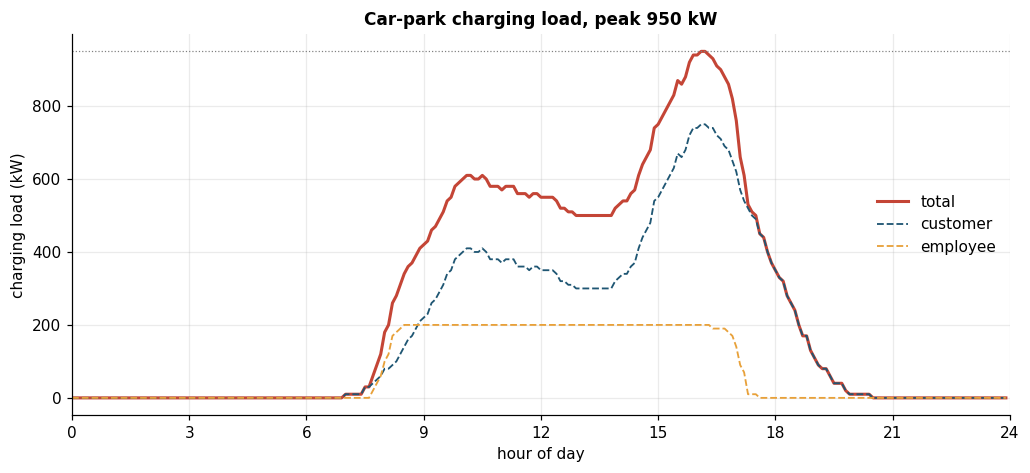

In [4]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(profile["hour"], profile["load_total_kw"], color=palette("total"), lw=2.0, label="total")
for name in categories:
    ax.plot(
        profile["hour"],
        profile[f"load_{name}_kw"],
        color=palette(name),
        lw=1.2,
        ls="--",
        label=name,
    )
ax.axhline(meta["peak_total_kw"], color="grey", lw=0.8, ls=":")
ax.set_xlabel("hour of day")
ax.set_ylabel("charging load (kW)")
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 3))
ax.set_title(f"Car-park charging load, peak {meta['peak_total_kw']:.0f} kW")
ax.legend()
save_figure(fig, "charging_load_curve", ROOT / "reports" / "figures")
plt.show()

## Summary

- The charging demand is built from behaviour: a mixture-of-Gaussians arrival
  and departure distribution per group, sampled into dwell times and counted
  into an occupancy curve.
- Customers spread across the day around a morning peak and an afternoon
  shoulder; employees fill a tight block over the working day.
- The summed load curve peaks in the middle of the day, where the two overlap,
  and well below every charger at once. That gap is the diversity a behavioural
  model captures and a worst-case sum misses.
- The generation engine and the fitted parameters are withheld; the committed
  figures show what they produce.